In [ ]:
# =============================
# IMPORT LIBRARY
# =============================

import pandas as pd
import numpy as np
import re
import json
import joblib
import matplotlib.pyplot as plt

from math import radians, sin, cos, sqrt, atan2

from sklearn.model_selection import (
    train_test_split,
    GridSearchCV
)

from sklearn.compose import ColumnTransformer

from sklearn.preprocessing import (
    StandardScaler,
    OneHotEncoder
)

from sklearn.pipeline import Pipeline

from sklearn.linear_model import LinearRegression

from sklearn.ensemble import RandomForestRegressor

from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

import tensorflow as tf

from tensorflow import keras
from tensorflow.keras import layers

from tabulate import tabulate

from sklearn.metrics import (
    r2_score,
    mean_absolute_error,
    mean_squared_error,
    mean_absolute_percentage_error
)

In [ ]:
# =============================
# LOAD DATA
# =============================

df = pd.read_csv("house_price_sleman.csv")

print(df.shape)

df.head()

(1349, 9)


,price,nav-link,description,listing-location,bed,bath,carport,surface_area,building_area
0,695000000.0,https://www.rumah123.com/properti/sleman/hos17...,Rumah 2 Lantai Baru di jalan Palagan Sleman Y...,"Ngaglik, Sleman",3.0,3.0,2.0,120.0,110.0
1,682000000.0,https://www.rumah123.com/properti/sleman/hos17...,RUMAH BARU DEKAT AL AZHAR DAN UGM,"Jombor, Sleman",3.0,2.0,1.0,102.0,126.0
2,580000000.0,https://www.rumah123.com/properti/sleman/hos17...,RUMAH ASRI DAN SEJUK DI BERBAH SLEMAN DEKAT PA...,"Berbah, Sleman",2.0,2.0,1.0,100.0,100.0
3,504000000.0,https://www.rumah123.com/properti/sleman/hos17...,Rumah Murah 5 Menit Dari Candi Prambanan Tersi...,"Prambanan, Sleman",3.0,1.0,1.0,109.0,67.0
4,275000000.0,https://www.rumah123.com/properti/sleman/hos17...,Rumah Murah Cicilan 1jt Di Moyudan Sleman,"Moyudan, Sleman",2.0,1.0,1.0,60.0,30.0


In [ ]:
# =============================
# PILIH KOLOM
# =============================

cols = [
    "price",
    "listing-location",
    "bed",
    "bath",
    "carport",
    "surface_area",
    "building_area"
]

df = df[cols].copy()

print(df.shape)

(1349, 7)


In [ ]:
# =============================
# CLEANING FUNCITON
# =============================

def clean_price(x):

    s = (
        str(x)
        .lower()
        .replace("rp", "")
        .replace(" ", "")
        .replace(",", ".")
    )

    mult = 1

    if "miliar" in s:
        mult = 1e9
        s = s.replace("miliar", "")

    elif "juta" in s:
        mult = 1e6
        s = s.replace("juta", "")

    s = re.sub(r"[^0-9\.]", "", s)

    return float(s) * mult if s != "" else np.nan


def clean_area(x):

    s = (
        str(x)
        .lower()
        .replace("m2", "")
        .replace("m²", "")
    )

    s = re.sub(r"[^0-9\.]", "", s)

    return float(s) if s != "" else np.nan

In [ ]:
# =============================
# DATA CLEANING
# =============================

df["price"] = df["price"].apply(clean_price)

df["surface_area"] = df["surface_area"].apply(clean_area)

df["building_area"] = df["building_area"].apply(clean_area)

df["bed"] = pd.to_numeric(df["bed"], errors="coerce")
df["bath"] = pd.to_numeric(df["bath"], errors="coerce")
df["carport"] = pd.to_numeric(df["carport"], errors="coerce")

df = df.dropna().reset_index(drop=True)

# HAPUS OUTLIER EKSTREM

Q1 = df["price"].quantile(0.25)
Q3 = df["price"].quantile(0.75)

IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

df = df[
    (df["price"] >= lower_bound) &
    (df["price"] <= upper_bound)
].reset_index(drop=True)

print("Shape setelah hapus outlier:", df.shape)

print(df.shape)


Shape setelah hapus outlier: (1045, 7)
(1045, 7)


In [ ]:
# =============================
# CLEANING LOCATION
# =============================

df["listing-location"] = (
    df["listing-location"]
    .str.replace(r"\s+", " ", regex=True)
    .str.strip()
)

In [ ]:
# =============================
# FITUR GEOGRAFIS
# =============================

location_coords = {

    "Ngaglik, Sleman": (-7.7060, 110.4010),
    "Depok, Sleman": (-7.7680, 110.4010),
    "Kalasan, Sleman": (-7.7670, 110.4720),
    "Mlati, Sleman": (-7.7420, 110.3600),
    "Sleman, Sleman": (-7.7150, 110.3550),
    "Ngemplak, Sleman": (-7.6940, 110.4300),
    "Gamping, Sleman": (-7.7990, 110.3210),
    "Godean, Sleman": (-7.7690, 110.2950),
    "Purwomartani, Sleman": (-7.7470, 110.4580),
    "Sleman, Yogyakarta": (-7.7150, 110.3550),
    "Condong Catur, Sleman": (-7.7570, 110.4010),
    "Berbah, Sleman": (-7.8170, 110.4380),
    "Prambanan, Sleman": (-7.7520, 110.4920),
    "Kaliurang, Sleman": (-7.6000, 110.4200),
    "Sayegan, Sleman": (-7.7230, 110.2890),
    "Caturtunggal, Sleman": (-7.7560, 110.3850),
    "Pakem, Sleman": (-7.6640, 110.4210),
    "Moyudan, Sleman": (-7.7680, 110.2490),
    "Cebongan, Sleman": (-7.7310, 110.3420),
    "Tempel, Sleman": (-7.6500, 110.3230),
    "Turi, Sleman": (-7.6530, 110.3690),
    "Jombor, Sleman": (-7.7470, 110.3620),
    "Sidoarum, Sleman": (-7.7630, 110.3320)

}

In [ ]:
# =============================
# TITIK REFRENSI
# =============================

UGM = (-7.7697, 110.3770)

MALIOBORO = (-7.7927, 110.3658)

CITY_CENTER = (-7.7956, 110.3695)

In [ ]:
# =============================
# FUNGSI HAVERSINE
# =============================
def haversine(
    lat1,
    lon1,
    lat2,
    lon2
):

    R = 6371

    dlat = radians(lat2 - lat1)
    dlon = radians(lon2 - lon1)

    a = (
        sin(dlat / 2) ** 2
        + cos(radians(lat1))
        * cos(radians(lat2))
        * sin(dlon / 2) ** 2
    )

    c = 2 * atan2(
        sqrt(a),
        sqrt(1 - a)
    )

    return R * c

In [ ]:
# =============================
# FITUR GEOGRAFIS
# =============================

df = df[
    df["listing-location"].isin(location_coords.keys())
].copy()

df["latitude"] = df["listing-location"].map(
    lambda x: location_coords[x][0]
)

df["longitude"] = df["listing-location"].map(
    lambda x: location_coords[x][1]
)

df["dist_ugm"] = df.apply(
    lambda r: haversine(
        r["latitude"],
        r["longitude"],
        UGM[0],
        UGM[1]
    ),
    axis=1
)

df["dist_malioboro"] = df.apply(
    lambda r: haversine(
        r["latitude"],
        r["longitude"],
        MALIOBORO[0],
        MALIOBORO[1]
    ),
    axis=1
)

df["dist_city_center"] = df.apply(
    lambda r: haversine(
        r["latitude"],
        r["longitude"],
        CITY_CENTER[0],
        CITY_CENTER[1]
    ),
    axis=1
)

df.head()

,price,listing-location,bed,bath,carport,surface_area,building_area,latitude,longitude,dist_ugm,dist_malioboro,dist_city_center
0,695000000.0,"Ngaglik, Sleman",3.0,3.0,2.0,120.0,110.0,-7.706,110.401,7.560640,10.391463,10.550261
1,682000000.0,"Jombor, Sleman",3.0,2.0,1.0,102.0,126.0,-7.747,110.362,3.017031,5.098825,5.466881
2,580000000.0,"Berbah, Sleman",2.0,2.0,1.0,100.0,100.0,-7.817,110.438,8.533709,8.400331,7.912553
3,504000000.0,"Prambanan, Sleman",3.0,1.0,1.0,109.0,67.0,-7.752,110.492,12.822239,14.621878,14.340549
4,275000000.0,"Moyudan, Sleman",2.0,1.0,1.0,60.0,30.0,-7.768,110.249,14.103580,13.157848,13.625714


In [ ]:
# =============================
# DATASET INFO
# =============================

print(tabulate(
    df.head(),
    headers="keys",
    tablefmt="grid"
))
,
print("\n")

print(tabulate(
    df.describe(),
    headers="keys",
    tablefmt="grid"
))

+----+----------+--------------------+-------+--------+-----------+----------------+-----------------+------------+-------------+------------+------------------+--------------------+
|    |    price | listing-location   |   bed |   bath |   carport |   surface_area |   building_area |   latitude |   longitude |   dist_ugm |   dist_malioboro |   dist_city_center |
+====+==========+====================+=======+========+===========+================+=================+============+=============+============+==================+====================+
|  0 | 6.95e+08 | Ngaglik, Sleman    |     3 |      3 |         2 |            120 |             110 |     -7.706 |     110.401 |    7.56064 |         10.3915  |           10.5503  |
+----+----------+--------------------+-------+--------+-----------+----------------+-----------------+------------+-------------+------------+------------------+--------------------+
|  1 | 6.82e+08 | Jombor, Sleman     |     3 |      2 |         1 |            102 | 

In [ ]:
# =============================
# CEK DISTRIBUSI HARGA
# =============================

print(df["price"].describe())

count    1.013000e+03
mean     6.884946e+08
std      2.862005e+08
min      2.170000e+08
25%      4.750000e+08
50%      6.140000e+08
75%      8.700000e+08
max      1.592000e+09
Name: price, dtype: float64


In [ ]:
# =============================
# SPLIT DATA
# =============================

X = df.drop("price", axis=1)

# LOG TRANSFORM TARGET
y = np.log1p(df["price"])

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [ ]:
# =============================
# PREPROCESSING
# =============================

num_cols = [
    "bed",
    "bath",
    "carport",
    "surface_area",
    "building_area",
    "latitude",
    "longitude",
    "dist_ugm",
    "dist_malioboro",
    "dist_city_center"
]

cat_cols = [
    "listing-location"
]

preprocessor = ColumnTransformer(
    [
        (
            "num",
            StandardScaler(),
            num_cols
        ),

        (
            "cat",
            OneHotEncoder(
                handle_unknown="ignore"
            ),
            cat_cols
        )
    ]
)

In [ ]:
# =============================
# FEATURE ENGINEERING RESULT
# =============================
X_transformed = preprocessor.fit_transform(X)

encoded_cols = preprocessor.named_transformers_[
    "cat"
].get_feature_names_out(cat_cols)

all_features = (
    num_cols +
    list(encoded_cols)
)

feature_df = pd.DataFrame({
    "Feature": all_features
})

feature_df

,Feature
0,bed
1,bath
2,carport
3,surface_area
4,building_area
5,latitude
6,longitude
7,dist_ugm
8,dist_malioboro
9,dist_city_center


In [ ]:
# ==================================================
# KONFIGURASI MODEL DAN HYPERPARAMETER
# ==================================================

print("="*60)
print("KONFIGURASI MODEL DAN HYPERPARAMETER")
print("="*60)

print("\n[1] Linear Regression")
print("Preprocessing : StandardScaler + OneHotEncoder")
print("Parameter     : Default")
print("Keterangan    : Baseline Model")

print("\n[2] Random Forest")
print("Preprocessing : StandardScaler + OneHotEncoder")

rf_param_grid = {
    "model__n_estimators": [100, 200],
    "model__max_depth": [None, 10, 20],
    "model__min_samples_split": [2, 5]
}

print("Parameter Grid:")
for k, v in rf_param_grid.items():
    print(f"{k} : {v}")

print("\n[3] Deep Neural Network")

learning_rates = [0.01, 0.001, 0.0005]

architectures = [
    [128, 64],
    [256, 128, 64],
    [512, 256, 128, 64]
]

print("Learning Rates :", learning_rates)
print("Architectures  :")

for arch in architectures:
    print(arch)

print("\nEarlyStopping : True")
print("Loss Function : Mean Squared Error")
print("Optimizer     : Adam")

KONFIGURASI MODEL DAN HYPERPARAMETER

[1] Linear Regression
Preprocessing : StandardScaler + OneHotEncoder
Parameter     : Default
Keterangan    : Baseline Model

[2] Random Forest
Preprocessing : StandardScaler + OneHotEncoder
Parameter Grid:
model__n_estimators : [100, 200]
model__max_depth : [None, 10, 20]
model__min_samples_split : [2, 5]

[3] Deep Neural Network
Learning Rates : [0.01, 0.001, 0.0005]
Architectures  :
[128, 64]
[256, 128, 64]
[512, 256, 128, 64]

EarlyStopping : True
Loss Function : Mean Squared Error
Optimizer     : Adam


In [ ]:
# =============================
# LINEAR REGRESSION
# =============================

lr_model = Pipeline([
    ("prep", preprocessor),
    ("model", LinearRegression())
])

lr_model.fit(
    X_train,
    y_train
)

pred_lr = lr_model.predict(
    X_test
)

In [ ]:
print("Pred LR Min :", pred_lr.min())
print("Pred LR Max :", pred_lr.max())

print("y_test Min :", y_test.min())
print("y_test Max :", y_test.max())

Pred LR Min : 19.577376323931293
Pred LR Max : 21.484843607362794
y_test Min : 19.352844828919817
y_test Max : 21.17434145694357


In [ ]:
# =============================
# RANDOM FOREST + GRID SEARCH
# =============================

rf_pipeline = Pipeline([
    ("prep", preprocessor),

    (
        "model",
        RandomForestRegressor(
            random_state=42
        )
    )
])

param_grid = {

    "model__n_estimators": [
        200,
        500
    ],

    "model__max_depth": [
        10,
        20,
        30,
        None
    ],

    "model__min_samples_split": [
        2,
        5,
        10
    ],

    "model__min_samples_leaf": [
        1,
        2,
        4
    ],

    "model__max_features": [
        "sqrt",
        "log2"
    ]
}

In [ ]:
# =============================
# TRAIN RANDOM FOREST
# =============================

grid_rf = GridSearchCV(
    rf_pipeline,
    param_grid,
    cv=5,
    scoring="neg_root_mean_squared_error",
    n_jobs=-1,
    verbose=1
)

grid_rf.fit(
    X_train,
    y_train
)

best_rf = grid_rf.best_estimator_

pred_rf = best_rf.predict(
    X_test
)

print(grid_rf.best_params_)

Fitting 5 folds for each of 144 candidates, totalling 720 fits
{'model__max_depth': 20, 'model__max_features': 'sqrt', 'model__min_samples_leaf': 1, 'model__min_samples_split': 2, 'model__n_estimators': 200}


In [ ]:
# =============================
# PREPROCESS UNTUK DNN
# =============================

X_train_p = preprocessor.fit_transform(
    X_train
)

X_test_p = preprocessor.transform(
    X_test
)

In [ ]:
# =============================
# BUILD DNN
# =============================

def build_dnn(
    input_dim,
    learning_rate,
    layer_config,
    dropout_rate
):

    model = keras.Sequential()

    model.add(
        layers.Input(
            shape=(input_dim,)
        )
    )

    for units in layer_config:

        model.add(
            layers.Dense(
                units,
                activation="relu"
            )
        )

        model.add(
            layers.BatchNormalization()
        )

        model.add(
            layers.Dropout(
                dropout_rate
            )
        )

    model.add(
        layers.Dense(1)
    )

    model.compile(

        optimizer=keras.optimizers.Adam(
            learning_rate=learning_rate
        ),

        loss=tf.keras.losses.Huber(),

        metrics=["mae"]

    )

    return model

In [ ]:
# =============================
# HYPERPARAMETER DNN
# =============================

learning_rates = [
    0.001,
    0.0005,
    0.0001
]

dropout_rates = [
    0.1,
    0.2,
    0.3
]

layer_configs = [

    [64,32],

    [128,64],

    [128,64,32]

]

In [ ]:
# =============================
# FINE TUNING DNN
# =============================

exp_results = []

best_rmse = np.inf

best_dnn = None

In [ ]:
# =============================
# TRAINING DNN
# =============================

from sklearn.metrics import (
    r2_score,
    mean_absolute_error,
    mean_squared_error,
    mean_absolute_percentage_error
)

for lr in learning_rates:

    for dropout in dropout_rates:

        for layers_cfg in layer_configs:

            print(
                f"LR={lr} "
                f"Dropout={dropout} "
                f"Layers={layers_cfg}"
            )

            model = build_dnn(
                X_train_p.shape[1],
                lr,
                layers_cfg,
                dropout
            )

            history = model.fit(

                X_train_p,

                y_train,

                validation_split=0.2,

                epochs=300,

                batch_size=16,

                verbose=0,

                callbacks=[

                    keras.callbacks.EarlyStopping(

                        monitor="val_loss",

                        patience=20,

                        restore_best_weights=True

                    )

                ]

            )

            pred = model.predict(
                X_test_p
            ).flatten()

            # =============================
            # METRIK PADA DATA LOG
            # =============================

            r2 = r2_score(
                y_test,
                pred
            )

            mae = mean_absolute_error(
                y_test,
                pred
            )

            rmse = np.sqrt(
                mean_squared_error(
                    y_test,
                    pred
                )
            )

            # =============================
            # MAPE PADA SKALA HARGA ASLI
            # =============================

            y_test_actual = np.expm1(y_test)

            pred_actual = np.expm1(pred)

            mape = mean_absolute_percentage_error(
                y_test_actual,
                pred_actual
            ) * 100

            exp_results.append({

                "learning_rate": lr,

                "dropout": dropout,

                "architecture": str(layers_cfg),

                "R2": r2,

                "MAE": mae,

                "RMSE": rmse,

                "MAPE (%)": mape

            })

            if rmse < best_rmse:

                best_rmse = rmse

                best_dnn = model

                pred_dnn = pred

LR=0.001 Dropout=0.1 Layers=[64, 32]
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step
LR=0.001 Dropout=0.1 Layers=[128, 64]
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step
LR=0.001 Dropout=0.1 Layers=[128, 64, 32]


7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step
LR=0.001 Dropout=0.2 Layers=[64, 32]


7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step
LR=0.001 Dropout=0.2 Layers=[128, 64]
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step
LR=0.001 Dropout=0.2 Layers=[128, 64, 32]
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step
LR=0.001 Dropout=0.3 Layers=[64, 32]
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step
LR=0.001 Dropout=0.3 Layers=[128, 64]
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step
LR=0.001 Dropout=0.3 Layers=[128, 64, 32]
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step
LR=0.0005 Dropout=0.1 Layers=[64, 32]
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step
LR=0.0005 Dropout=0.1 Layers=[128, 64]
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step
LR=0.0005 Dropout=0.1 Layers=[128, 64, 32]
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step
LR=0.0005 Dropout=0.2 Layers=[64, 32]
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step
LR=0.0005 Dropout=0.2 Layers=[128, 64]
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step
LR=0.0005 Dropout=0.2 Layers=[128, 64, 32]
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step
LR=0.0005 Dropout=0.3 Layers=[64, 32]
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step
LR=0.0005 Dropout=0.3 Layers=[1

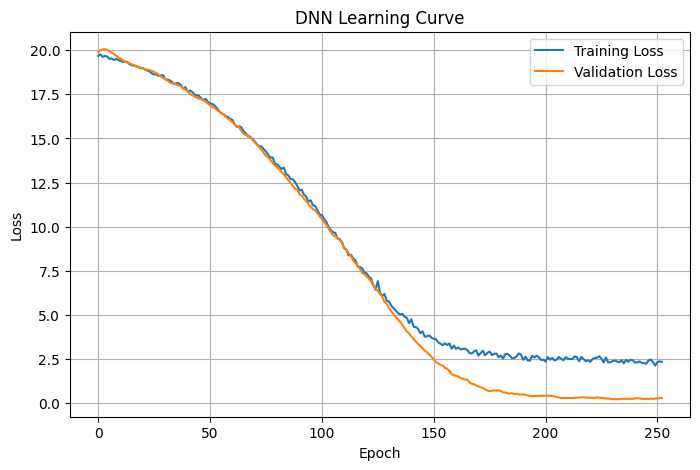

In [ ]:
# =============================
# VISUALISASI TRAINING DNN
# =============================
plt.figure(figsize=(8,5))

plt.plot(
    history.history["loss"],
    label="Training Loss"
)

plt.plot(
    history.history["val_loss"],
    label="Validation Loss"
)

plt.title(
    "DNN Learning Curve"
)

plt.xlabel("Epoch")

plt.ylabel("Loss")

plt.legend()

plt.grid(True)

plt.show()

In [ ]:
# =============================
# FINE TUNING RESULT
# =============================

exp_df = pd.DataFrame(
    exp_results
).sort_values(
    "RMSE"
)

exp_df

,learning_rate,dropout,architecture,R2,MAE,RMSE,MAPE (%)
0,0.0010,0.1,"[64, 32]",0.956364,0.065722,0.082323,6.423254
5,0.0010,0.2,"[128, 64, 32]",0.902804,0.096072,0.122863,9.356035
2,0.0010,0.1,"[128, 64, 32]",0.893019,0.100215,0.128899,9.664362
3,0.0010,0.2,"[64, 32]",0.850722,0.114155,0.152263,11.504707
8,0.0010,0.3,"[128, 64, 32]",0.839753,0.123799,0.157758,11.744018
9,0.0005,0.1,"[64, 32]",0.803565,0.115732,0.174665,10.805402
11,0.0005,0.1,"[128, 64, 32]",0.606650,0.199777,0.247165,18.892568
4,0.0010,0.2,"[128, 64]",0.594939,0.178410,0.250817,17.337086
10,0.0005,0.1,"[128, 64]",0.573314,0.186611,0.257425,17.066072
1,0.0010,0.1,"[128, 64]",0.526206,0.205154,0.271264,19.139596


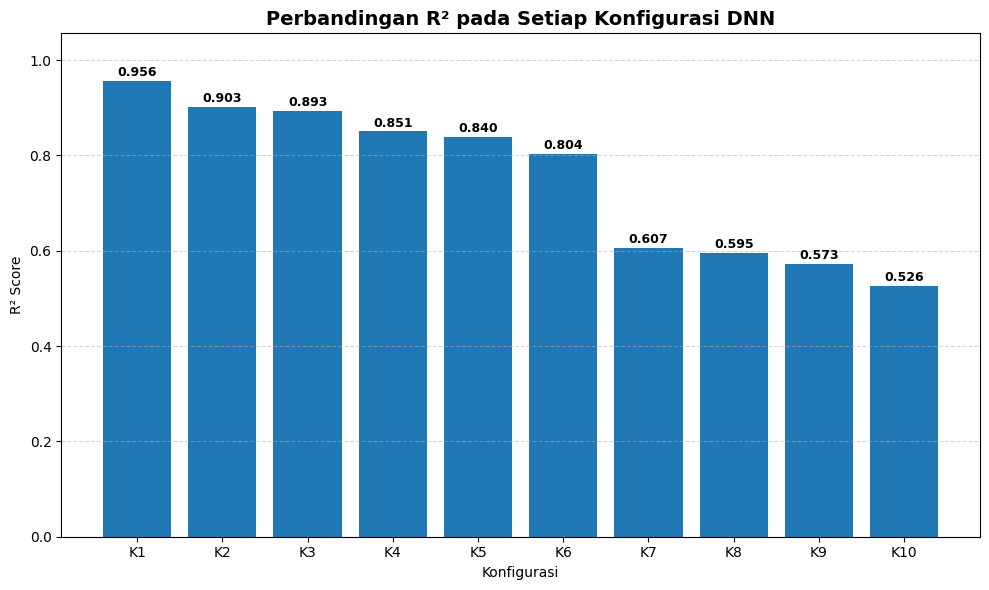


TOP 10 KONFIGURASI DNN



,Konfigurasi,learning_rate,dropout,architecture,R2,MAE,RMSE
0,K1,0.0010,0.1,"[64, 32]",0.956364,0.065722,0.082323
1,K2,0.0010,0.2,"[128, 64, 32]",0.902804,0.096072,0.122863
2,K3,0.0010,0.1,"[128, 64, 32]",0.893019,0.100215,0.128899
3,K4,0.0010,0.2,"[64, 32]",0.850722,0.114155,0.152263
4,K5,0.0010,0.3,"[128, 64, 32]",0.839753,0.123799,0.157758
5,K6,0.0005,0.1,"[64, 32]",0.803565,0.115732,0.174665
6,K7,0.0005,0.1,"[128, 64, 32]",0.606650,0.199777,0.247165
7,K8,0.0010,0.2,"[128, 64]",0.594939,0.178410,0.250817
8,K9,0.0005,0.1,"[128, 64]",0.573314,0.186611,0.257425
9,K10,0.0010,0.1,"[128, 64]",0.526206,0.205154,0.271264


In [ ]:
# =============================
# VISUALISASI TOP 10 KONFIGURASI DNN
# =============================

import pandas as pd
import matplotlib.pyplot as plt

# Ambil hasil fine tuning
plot_df = exp_df.copy()

# Urutkan berdasarkan R² terbaik
plot_df = (
    plot_df
    .sort_values("R2", ascending=False)
    .head(10)
    .reset_index(drop=True)
)

# Buat kode konfigurasi sederhana
plot_df["Konfigurasi"] = [
    f"K{i+1}"
    for i in range(len(plot_df))
]

# =============================
# GRAFIK
# =============================

plt.figure(figsize=(10,6))

bars = plt.bar(
    plot_df["Konfigurasi"],
    plot_df["R2"]
)

plt.title(
    "Perbandingan R² pada Setiap Konfigurasi DNN",
    fontsize=14,
    fontweight="bold"
)

plt.xlabel(
    "Konfigurasi"
)

plt.ylabel(
    "R² Score"
)

plt.ylim(
    0,
    plot_df["R2"].max() + 0.1
)

plt.grid(
    axis="y",
    linestyle="--",
    alpha=0.5
)

# Tambahkan nilai di atas batang
for bar in bars:

    height = bar.get_height()

    plt.text(
        bar.get_x() + bar.get_width()/2,
        height + 0.01,
        f"{height:.3f}",
        ha="center",
        fontsize=9,
        fontweight="bold"
    )

plt.tight_layout()
plt.show()

# =============================
# TABEL KONFIGURASI
# =============================

hasil_konfigurasi = plot_df[
    [
        "Konfigurasi",
        "learning_rate",
        "dropout",
        "architecture",
        "R2",
        "MAE",
        "RMSE"
    ]
]

print("\nTOP 10 KONFIGURASI DNN\n")

display(
    hasil_konfigurasi
)

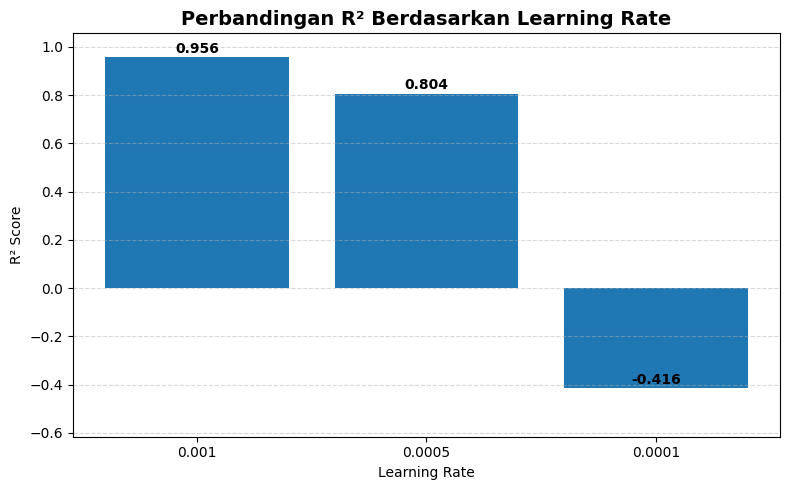


R² Terbaik pada Setiap Learning Rate


,learning_rate,R2
2,0.0010,0.956364
1,0.0005,0.803565
0,0.0001,-0.416271


In [ ]:
# =============================
# GRAFIK R² BERDASARKAN LEARNING RATE
# =============================

import pandas as pd
import matplotlib.pyplot as plt

# Ambil R² terbaik pada setiap learning rate
lr_plot = (
    exp_df
    .groupby("learning_rate")["R2"]
    .max()
    .reset_index()
    .sort_values("learning_rate", ascending=False)
)

plt.figure(figsize=(8,5))

bars = plt.bar(
    lr_plot["learning_rate"].astype(str),
    lr_plot["R2"]
)

plt.title(
    "Perbandingan R² Berdasarkan Learning Rate",
    fontsize=14,
    fontweight="bold"
)

plt.xlabel(
    "Learning Rate"
)

plt.ylabel(
    "R² Score"
)

plt.grid(
    axis="y",
    linestyle="--",
    alpha=0.5
)

for bar in bars:

    height = bar.get_height()

    plt.text(
        bar.get_x() + bar.get_width()/2,
        height + 0.02,
        f"{height:.3f}",
        ha="center",
        fontsize=10,
        fontweight="bold"
    )

plt.ylim(
    min(lr_plot["R2"]) - 0.2,
    max(lr_plot["R2"]) + 0.1
)

plt.tight_layout()
plt.show()

print("\nR² Terbaik pada Setiap Learning Rate")
display(lr_plot)

In [ ]:
# =============================
# MODEL EVALUASI
# =============================

pred_lr_real = np.expm1(pred_lr)

pred_rf_real = np.expm1(pred_rf)

pred_dnn_real = np.expm1(pred_dnn)

y_test_real = np.expm1(y_test)

results = pd.DataFrame({

    "Linear Regression": [

        r2_score(
            y_test_real,
            pred_lr_real
        ),

        mean_absolute_error(
            y_test_real,
            pred_lr_real
        ),

        np.sqrt(
            mean_squared_error(
                y_test_real,
                pred_lr_real
            )
        ),

        mean_absolute_percentage_error(
            y_test_real,
            pred_lr_real
        ) * 100
    ],

    "Random Forest": [

        r2_score(
            y_test_real,
            pred_rf_real
        ),

        mean_absolute_error(
            y_test_real,
            pred_rf_real
        ),

        np.sqrt(
            mean_squared_error(
                y_test_real,
                pred_rf_real
            )
        ),

        mean_absolute_percentage_error(
            y_test_real,
            pred_rf_real
        ) * 100
    ],

    "DNN": [

        r2_score(
            y_test_real,
            pred_dnn_real
        ),

        mean_absolute_error(
            y_test_real,
            pred_dnn_real
        ),

        np.sqrt(
            mean_squared_error(
                y_test_real,
                pred_dnn_real
            )
        ),

        mean_absolute_percentage_error(
            y_test_real,
            pred_dnn_real
        ) * 100
    ]

},
index=[
    "R2",
    "MAE",
    "RMSE",
    "MAPE (%)"
]).T

print(results)

                         R2           MAE          RMSE  MAPE (%)
Linear Regression  0.885033  5.099927e+07  9.585389e+07  7.027927
Random Forest      0.950995  2.700817e+07  6.258112e+07  3.374138
DNN                0.949654  4.429250e+07  6.343132e+07  6.423254


In [ ]:
# =============================
# UJI NORMALITAS
# =============================
from scipy.stats import shapiro

error_lr = np.abs(y_test - pred_lr)
error_rf = np.abs(y_test - pred_rf)
error_dnn = np.abs(y_test - pred_dnn)

print("=== SHAPIRO-WILK TEST ===")

for name, error in {
    "Linear Regression": error_lr,
    "Random Forest": error_rf,
    "DNN": error_dnn
}.items():

    stat, p = shapiro(error)

    print(f"{name}")
    print(f"Statistic = {stat:.4f}")
    print(f"P-value = {p:.4f}")

    if p > 0.05:
        print("Normal")
    else:
        print("Tidak Normal")

    print()

=== SHAPIRO-WILK TEST ===
Linear Regression
Statistic = 0.7455
P-value = 0.0000
Tidak Normal

Random Forest
Statistic = 0.6294
P-value = 0.0000
Tidak Normal

DNN
Statistic = 0.9286
P-value = 0.0000
Tidak Normal



In [ ]:
from scipy.stats import f_oneway
from scipy.stats import kruskal

p_lr = shapiro(error_lr).pvalue
p_rf = shapiro(error_rf).pvalue
p_dnn = shapiro(error_dnn).pvalue

print("=== UJI PERBEDAAN MODEL ===")

if (
    p_lr > 0.05 and
    p_rf > 0.05 and
    p_dnn > 0.05
):

    print("Menggunakan ANOVA")

    stat, p = f_oneway(
        error_lr,
        error_rf,
        error_dnn
    )

else:

    print("Menggunakan Kruskal-Wallis")

    stat, p = kruskal(
        error_lr,
        error_rf,
        error_dnn
    )

print(f"Statistic = {stat:.4f}")
print(f"P-value = {p:.4f}")

if p < 0.05:
    print("Terdapat perbedaan signifikan")
else:
    print("Tidak terdapat perbedaan signifikan")

=== UJI PERBEDAAN MODEL ===
Menggunakan Kruskal-Wallis
Statistic = 104.3228
P-value = 0.0000
Terdapat perbedaan signifikan


In [ ]:
!pip install scikit-posthocs

In [ ]:
# =============================
# POST HOC TEST
# =============================
import scikit_posthocs as sp

data_posthoc = pd.DataFrame({

    "error": np.concatenate([
        error_lr,
        error_rf,
        error_dnn
    ]),

    "model": (
        ["Linear Regression"] * len(error_lr)
        + ["Random Forest"] * len(error_rf)
        + ["DNN"] * len(error_dnn)
    )

})

posthoc_result = sp.posthoc_dunn(
    data_posthoc,
    val_col="error",
    group_col="model",
    p_adjust="bonferroni"
)

print(posthoc_result)

                            DNN  Linear Regression  Random Forest
DNN                1.000000e+00       1.000000e+00   3.240163e-18
Linear Regression  1.000000e+00       1.000000e+00   2.309710e-18
Random Forest      3.240163e-18       2.309710e-18   1.000000e+00


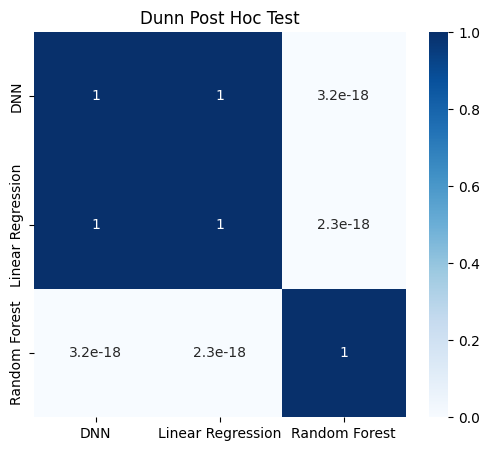

In [ ]:
# =============================
# HEATMAP POST HOC
# =============================
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(6,5))

sns.heatmap(
    posthoc_result,
    annot=True,
    cmap="Blues"
)

plt.title("Dunn Post Hoc Test")

plt.show()

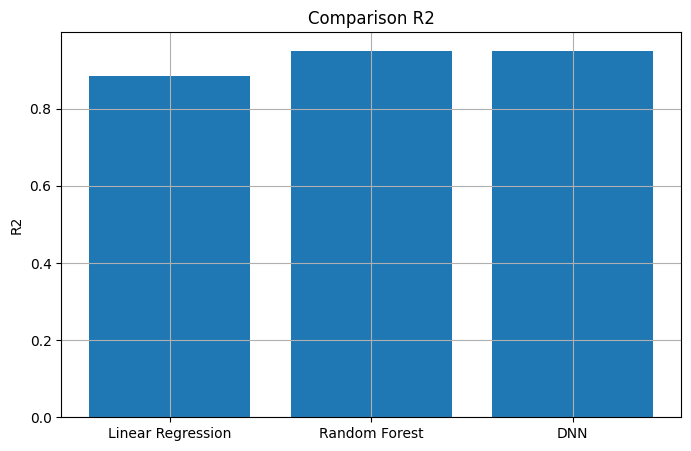

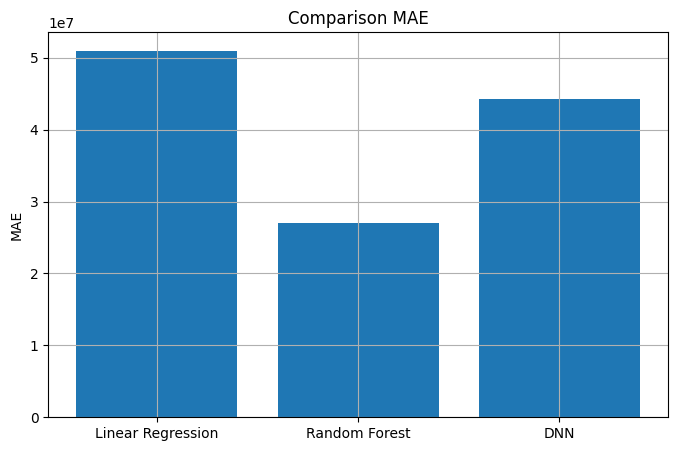

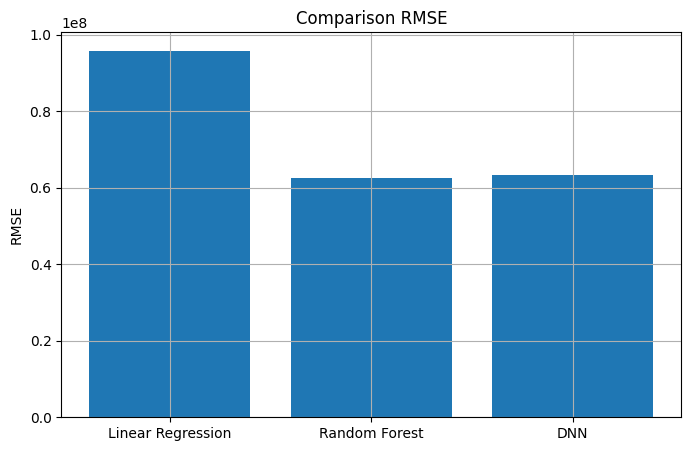

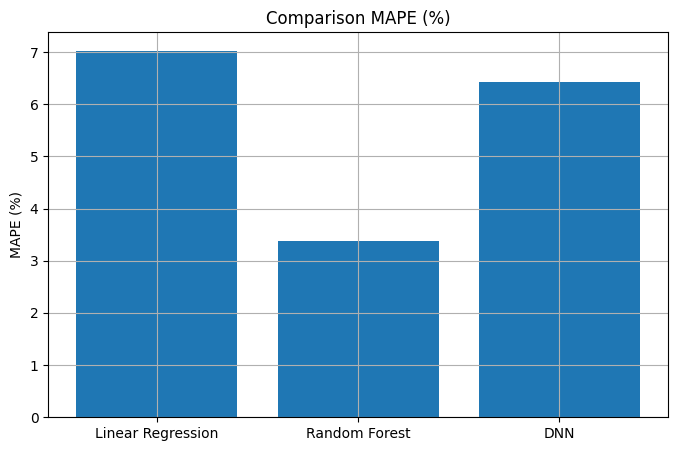

In [ ]:
# =============================
# VISUALISASI PERBANDINGAN MODEL
# =============================

metrics = [
    "R2",
    "MAE",
    "RMSE",
    "MAPE (%)"
]

for metric in metrics:

    plt.figure(figsize=(8,5))

    plt.bar(
        results.index,
        results[metric]
    )

    plt.title(
        f"Comparison {metric}"
    )

    plt.ylabel(metric)

    plt.grid()

    plt.show()

In [ ]:
# =============================
# SAVE MODEL TERBAIK
# =============================
best_model_name = results["RMSE"].idxmin()

print(
    "Best Model:",
    best_model_name
)

joblib.dump(
    preprocessor,
    "preprocessor.pkl"
)

if best_model_name == "DNN":

    best_dnn.save(
        "best_model_tf.h5"
    )

else:

    joblib.dump(
        best_rf if best_model_name == "Random Forest"
        else lr_model,
        "best_model.pkl"
    )

results.to_csv(
    "model_results.csv"
)

print("Model saved successfully")

Best Model: Random Forest
Model saved successfully


In [ ]:
print(preprocessor.feature_names_in_)

['listing-location' 'bed' 'bath' 'carport' 'surface_area' 'building_area'
 'latitude' 'longitude' 'dist_ugm' 'dist_malioboro' 'dist_city_center']


In [ ]:
import joblib

preprocessor = joblib.load("preprocessor.pkl")

print(type(preprocessor))

if hasattr(preprocessor, "feature_names_in_"):
    print(preprocessor.feature_names_in_)

<class 'sklearn.compose._column_transformer.ColumnTransformer'>
['listing-location' 'bed' 'bath' 'carport' 'surface_area' 'building_area'
 'latitude' 'longitude' 'dist_ugm' 'dist_malioboro' 'dist_city_center']


In [ ]:
import joblib

model = joblib.load("best_model.pkl")

print(model)

Pipeline(steps=[('prep',
                 ColumnTransformer(transformers=[('num', StandardScaler(),
                                                  ['bed', 'bath', 'carport',
                                                   'surface_area',
                                                   'building_area', 'latitude',
                                                   'longitude', 'dist_ugm',
                                                   'dist_malioboro',
                                                   'dist_city_center']),
                                                 ('cat',
                                                  OneHotEncoder(handle_unknown='ignore'),
                                                  ['listing-location'])])),
                ('model',
                 RandomForestRegressor(max_depth=20, max_features='sqrt',
                                       n_estimators=200, random_state=42))])


In [ ]:
results_dict = {
    "Linear Regression": {
        "R2": float(results.loc["Linear Regression", "R2"]),
        "MAE": float(results.loc["Linear Regression", "MAE"]),
        "RMSE": float(results.loc["Linear Regression", "RMSE"]),
        "MAPE": float(results.loc["Linear Regression", "MAPE (%)"])
    },

    "Random Forest": {
        "R2": float(results.loc["Random Forest", "R2"]),
        "MAE": float(results.loc["Random Forest", "MAE"]),
        "RMSE": float(results.loc["Random Forest", "RMSE"]),
        "MAPE": float(results.loc["Random Forest", "MAPE (%)"])
    },

    "DNN": {
        "R2": float(results.loc["DNN", "R2"]),
        "MAE": float(results.loc["DNN", "MAE"]),
        "RMSE": float(results.loc["DNN", "RMSE"]),
        "MAPE": float(results.loc["DNN", "MAPE (%)"])
    }
}

with open("model_results.json", "w") as f:
    json.dump(results_dict, f, indent=4)

print("model_results.json berhasil dibuat")

model_results.json berhasil dibuat


In [ ]:
from google.colab import files
files.download("model_results.json")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
import sklearn
print(sklearn.__version__)

1.6.1


In [ ]:
import sklearn
import tensorflow
import pandas

print("sklearn :", sklearn.__version__)
print("tensorflow :", tensorflow.__version__)
print("pandas :", pandas.__version__)

sklearn : 1.6.1
tensorflow : 2.20.0
pandas : 2.2.2


In [ ]:
import sklearn
print(sklearn.__version__)

1.6.1


In [ ]:
!pip install streamlit
import sklearn
import streamlit as st

st.write("sklearn version:", sklearn.__version__)

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.2/9.2 MB 39.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.3/11.3 MB 58.9 MB/s eta 0:00:00


2026-06-16 13:18:36.505 WARNING streamlit.runtime.scriptrunner_utils.script_run_context: Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-06-16 13:18:37.224 
  command:

    streamlit run /usr/local/lib/python3.12/dist-packages/colab_kernel_launcher.py [ARGUMENTS]
2026-06-16 13:18:37.225 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-06-16 13:18:37.226 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-06-16 13:18:37.227 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-06-16 13:18:37.227 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-06-16 13:18:37.228 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.


In [ ]:
import joblib

model = joblib.load("best_model.pkl")

print(type(model))
print(model)

<class 'sklearn.pipeline.Pipeline'>
Pipeline(steps=[('prep',
                 ColumnTransformer(transformers=[('num', StandardScaler(),
                                                  ['bed', 'bath', 'carport',
                                                   'surface_area',
                                                   'building_area', 'latitude',
                                                   'longitude', 'dist_ugm',
                                                   'dist_malioboro',
                                                   'dist_city_center']),
                                                 ('cat',
                                                  OneHotEncoder(handle_unknown='ignore'),
                                                  ['listing-location'])])),
                ('model',
                 RandomForestRegressor(max_depth=20, max_features='sqrt',
                                       n_estimators=200, random_state=42))])


In [ ]:
if hasattr(model, "named_steps"):
    print(model.named_steps["model"])

RandomForestRegressor(max_depth=20, max_features='sqrt', n_estimators=200,
                      random_state=42)


In [ ]:
import joblib
import pandas as pd

model = joblib.load("best_model.pkl")

sample = pd.DataFrame([{
    "listing-location": "Ngaglik, Sleman",
    "bed": 3,
    "bath": 2,
    "carport": 1,
    "surface_area": 120,
    "building_area": 90,
    "latitude": -7.706,
    "longitude": 110.401,
    "dist_ugm": 7.56,
    "dist_malioboro": 10.39,
    "dist_city_center": 10.55
}])

print(model.predict(sample))

[20.21746035]
